In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from src.scripts.rf_tuning import tune_rf_model

In [2]:
def train_tune_and_print_results(path_to_training_data:str, train_by_sessions, test_sessions):
    data = pd.read_csv(path_to_training_data)
    #data = data[data['session']!=41].reset_index(drop=True) ### FOCUS HERE: I'VE REMOVED A SUSPICIOUS SESSION
    best_model, importances = tune_rf_model(data, 'e2etime', train_by_sessions, test_sessions)
    return best_model, importances

In [3]:
path_to_feature_data = "../data/landlord_data_for_rf_training_w_lagged_features_coldstart.csv"

In [4]:
rf_model, results_df = train_tune_and_print_results(path_to_feature_data, train_by_sessions=True, test_sessions=[36, 37, 38, 39, 40, 41, 42, 43])

Session Splitting Active | Train Size: 62008 | Test Size: 16526 (Holdout Sessions: [36, 37, 38, 39, 40, 41, 42, 43])

USER'S BASELINE MODEL (Overfit Corrected)
Baseline Train R2 (Log Scale): 0.8390
Baseline Test R2  (Log Scale): 0.7354

STARTING RANDOMIZED SEARCH CV TUNING
Searching for optimal parameters bounded for robust generalization...
Fitting 3 folds for each of 90 candidates, totalling 270 fits

Optimal Hyperparameters Discovered:
 - max_depth: 10
 - max_features: 1.0
 - min_samples_leaf: 5
 - n_estimators: 100

BEST TUNED MODEL EVALUATION
Tuned Train R2 (Log Scale): 0.8527
Tuned Test R2  (Log Scale): 0.7961
Tuned Test MSE (Real Units): 330.6780
Tuned Test MAE (Real Units): 2.2390

[Tuned Model] Feature Importances:
                        Feature  Importance
                  is_cold_start    0.360921
           gpu_warm_results_sec    0.232354
               others_len_queue    0.203666
           gpu_cold_results_sec    0.105329
                       iat_fqdn    0.019230
  

In [38]:
import joblib

# Save tuned RF model to a file
# Use .joblib  as the extension
joblib.dump(rf_model, '../models/tuned_faas_rf_v1.joblib')

print("Model saved successfully!")

Model saved successfully!


In [9]:
results_df.columns

Index(['session', 'fqdn', 'tid', 'e2etime', 'rf_prediction', 'absolute_error',
       'squared_error', 'percentage_relative_error', 'is_test'],
      dtype='object')

In [10]:
results_df[results_df.is_test==True]['session'].unique()

array([36, 37, 38, 39, 40, 41, 42, 43])

In [11]:
results_df[results_df.is_test==True][['fqdn', 'percentage_relative_error']].groupby('fqdn').mean()

,percentage_relative_error
fqdn,
cupy-0-0.0.1,-6.915115
cupy-1-0.0.1,-14.529655
cupy-2-0.0.1,-10.183141
cupy-4-0.0.1,-15.279622
onnx-roberta-0-0.0.1,-41.291390
onnx-roberta-1-0.0.1,-20.523078
onnx-roberta-2-0.0.1,-32.719489
onnx-roberta-3-0.0.1,-23.195910
onnx-roberta-4-0.0.1,-9.774154


Comparing baseline rf model results with the current estimation errors

In [12]:
current_estimates = pd.read_csv("../data/current_estimation_model_raw_error_data.csv")

In [13]:
results_df.to_csv("../data/baseline_rf_model_error_data.csv", index=False)

In [14]:
current_estimates.columns

Index(['fqdn', 'tid', 'e2etime', 'gpu_est_total', 'absolute_error',
       'squared_error', 'percentage_relative_error', 'session'],
      dtype='object')

### Now let's compare the current estimate with the baseline RF model estimates. Since the RF model was trained on session 0-35, we'll only consider sessions 35-43(remember we have 44 sessions in total)

In [15]:
common_fqdns = set(current_estimates.fqdn.unique()).intersection(set(results_df.fqdn.unique()))
current_rel_error = current_estimates[current_estimates.session>35][['fqdn', 'percentage_relative_error']].groupby('fqdn', as_index=False).mean()
baseline_rf_error = results_df[results_df.is_test==True][['fqdn', 'percentage_relative_error']].groupby('fqdn', as_index=False).mean()
current_rel_error = current_rel_error[current_rel_error.fqdn.isin(common_fqdns)].reset_index(drop=True)
baseline_rf_error = baseline_rf_error[baseline_rf_error.fqdn.isin(common_fqdns)].reset_index(drop=True)

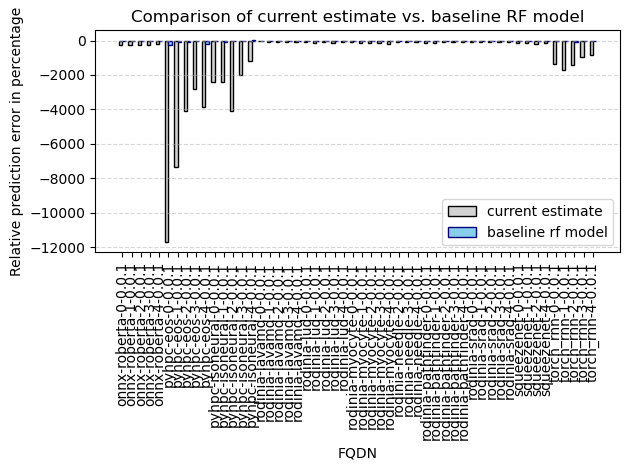

In [16]:
save_path = '../plots/error_comparison_is_cold_start.png'
x = np.arange(len(current_rel_error['fqdn']))  # The label locations
width = 0.35                    # The width of each bar

# 2. Create the figure and plot two sets of bars
# Subtracting/adding width/2 offsets them so they sit side-by-side
plt.bar(x - width/2, current_rel_error['percentage_relative_error'], width, label='current estimate', color='lightgray', edgecolor='black')
plt.bar(x + width/2, baseline_rf_error['percentage_relative_error'], width, label='baseline rf model', color='skyblue', edgecolor='navy')

# 3. Aesthetics & Labels
plt.xlabel('FQDN')
plt.ylabel('Relative prediction error in percentage')
plt.title('Comparison of current estimate vs. baseline RF model')

# Set the x-ticks to be exactly in the middle of the grouped bars
plt.xticks(x, current_rel_error['fqdn'].astype(str), rotation=90)

# Add a legend to distinguish the bars
plt.legend()

# Add a grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Finalize
plt.tight_layout()
plt.savefig(save_path)

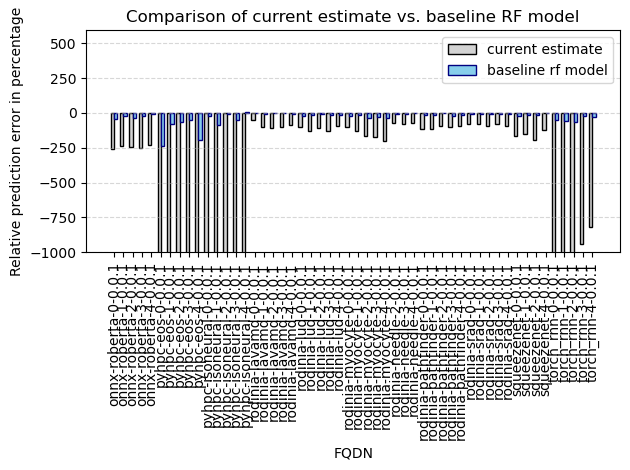

In [17]:
save_path = '../plots/error_comparison_is_cold_start.png'
x = np.arange(len(current_rel_error['fqdn']))  # The label locations
width = 0.35                    # The width of each bar

# 2. Create the figure and plot two sets of bars
# Subtracting/adding width/2 offsets them so they sit side-by-side
plt.bar(x - width/2, current_rel_error['percentage_relative_error'], width, label='current estimate', color='lightgray', edgecolor='black')
plt.bar(x + width/2, baseline_rf_error['percentage_relative_error'], width, label='baseline rf model', color='skyblue', edgecolor='navy')

# 3. Aesthetics & Labels
plt.xlabel('FQDN')
plt.ylabel('Relative prediction error in percentage')
plt.title('Comparison of current estimate vs. baseline RF model')

# Set the x-ticks to be exactly in the middle of the grouped bars
plt.xticks(x, current_rel_error['fqdn'].astype(str), rotation=90)

# Add a legend to distinguish the bars
plt.legend()

# Add a grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(-1000)
# 4. Finalize
plt.tight_layout()
# plt.savefig(save_path)

In [18]:
merged_df = current_rel_error.merge(baseline_rf_error, on='fqdn')

In [19]:
merged_df = merged_df.rename({"percentage_relative_error_x":"current_relative_error", "percentage_relative_error_y":"rf_model_relative_error"}, axis=1)

In [20]:
merged_df['improvement'] = merged_df['rf_model_relative_error'] - merged_df['current_relative_error']

In [21]:
merged_df.sort_values(by='improvement', ascending=False)

,fqdn,current_relative_error,rf_model_relative_error,improvement
5,pyhpc-eos-0-0.0.1,-11708.185213,-233.881424,11474.303789
6,pyhpc-eos-1-0.0.1,-7367.344222,-82.237399,7285.106823
12,pyhpc-isoneural-2-0.0.1,-4098.155148,-4.921324,4093.233824
7,pyhpc-eos-2-0.0.1,-4081.820638,-64.559411,4017.261227
9,pyhpc-eos-4-0.0.1,-3830.728941,-190.853998,3639.874942
8,pyhpc-eos-3-0.0.1,-2803.726939,-49.585998,2754.140941
10,pyhpc-isoneural-0-0.0.1,-2419.528582,-24.871359,2394.657222
11,pyhpc-isoneural-1-0.0.1,-2414.330970,-85.033958,2329.297012
13,pyhpc-isoneural-3-0.0.1,-2005.412672,-51.532143,1953.880529
48,torch_rnn-1-0.0.1,-1729.158058,-54.969109,1674.188949


In [22]:
results_df[results_df.is_test==True]['absolute_error'].mean(), results_df[results_df.is_test==True]['squared_error'].mean() 

(2.2390255050272843, 330.67802313710445)

We have seen from our previous analysis that session 41 is quite anomalous, with out of distribution e2etimes. We will ignore it for now

In [23]:
results_df[(results_df.is_test==True) & (results_df.session!=41)]['absolute_error'].mean()

0.5194456993762919

In [24]:
results_df[(results_df.is_test==True) & (results_df.session!=41)]['squared_error'].mean()

2.159039320958259

In [25]:
results_df[(results_df.is_test==True) & (results_df.session!=41)]['percentage_relative_error'].mean()

-17.564679295686908

In [34]:
len(results_df[(results_df.session>35) & (results_df.session!=41)])

15048

In [28]:
results_df[(results_df.session>35) & (results_df.session!=41)][['fqdn', 'e2etime', 'rf_prediction', 'absolute_error', 'squared_error', 'percentage_relative_error']].groupby('fqdn').mean().sort_values(by='percentage_relative_error')

,e2etime,rf_prediction,absolute_error,squared_error,percentage_relative_error
fqdn,,,,,
pyhpc-eos-0-0.0.1,3.853172,2.658704,1.643982,24.443192,-319.694301
pyhpc-eos-4-0.0.1,2.037581,2.317218,0.622918,1.237491,-236.915902
pyhpc-eos-1-0.0.1,4.145709,2.242577,2.451415,44.031679,-95.885590
pyhpc-isoneural-1-0.0.1,7.803349,5.942667,2.220878,27.242599,-87.587417
pyhpc-eos-2-0.0.1,2.696285,2.297096,0.528182,0.893181,-76.778767
torch_rnn-2-0.0.1,5.038995,4.879742,0.845454,3.819391,-74.064192
pyhpc-isoneural-3-0.0.1,3.574986,2.351318,1.490820,15.346623,-64.485392
pyhpc-eos-3-0.0.1,3.851988,3.192926,0.865085,3.591439,-64.471280
torch_rnn-0-0.0.1,4.739390,4.597896,0.845855,3.828071,-59.378857


In [30]:
results_df[(results_df.session>35) & (results_df.session!=41)]['e2etime'].describe()

count    15048.000000
mean         1.783248
std          2.323237
min          0.016947
25%          0.485883
50%          1.334301
75%          1.937858
max         38.360156
Name: e2etime, dtype: float64

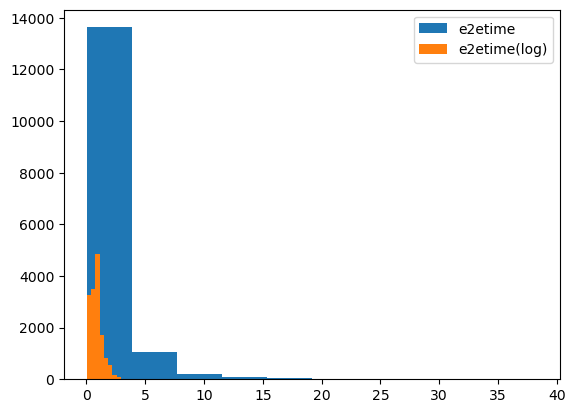

In [32]:
plt.figure()
plt.hist(results_df[(results_df.session>35) & (results_df.session!=41)]['e2etime'].values, label='e2etime')
plt.hist(np.log1p(results_df[(results_df.session>35) & (results_df.session!=41)]['e2etime'].values), label='e2etime(log)')
plt.legend()
plt.show()


<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/var/folders/0c/stdc2__157d9yghh3sz_pj040000gn/T/ipykernel_84017/3511933567.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_xlabel('$\log(1 + e2etime)$')


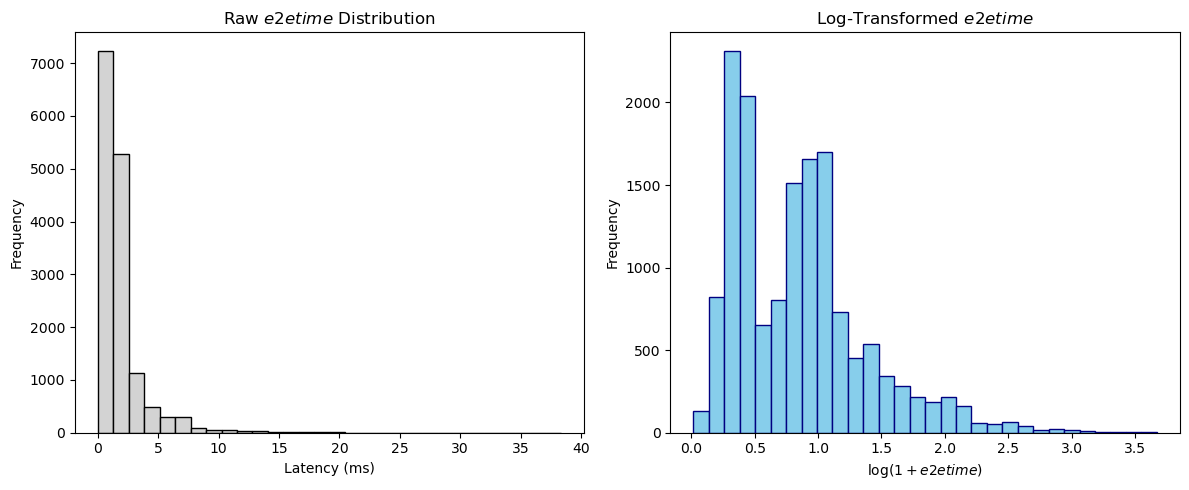

In [33]:
data_filter = (results_df.session > 35) & (results_df.session != 41)
raw_values = results_df[data_filter]['e2etime'].values
log_values = np.log1p(raw_values)

# 2. Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Raw Latency (The "Skewed" View)
ax1.hist(raw_values, bins=30, color='lightgray', edgecolor='black')
ax1.set_title('Raw $e2etime$ Distribution')
ax1.set_xlabel('Latency (ms)')
ax1.set_ylabel('Frequency')

# Plot 2: Log Latency (The "Normalized" View)
ax2.hist(log_values, bins=30, color='skyblue', edgecolor='navy')
ax2.set_title('Log-Transformed $e2etime$')
ax2.set_xlabel('$\log(1 + e2etime)$')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()